In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import pyro
import pyro.distributions as dist
from pyro.nn import PyroModule, PyroSample
import torch.nn as nn
from pyro.infer import Predictive

###PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

###Forward and Backward Selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import statsmodels.api as sm

# HMC
from pyro.infer import MCMC, NUTS

# variational inference
from pyro.infer import SVI, Trace_ELBO
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal
from tqdm.auto import trange
from tqdm.notebook import trange

import matplotlib as mpl
import os
import sys
import math

In [31]:
sys.path.append(
    r"C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior"
)

In [32]:
from optbnn.gp.models.gpr import GPR
from optbnn.gp import kernels, mean_functions, priors
from optbnn.bnn.reparam_nets import GaussianMLPReparameterization
from optbnn.bnn.nets.mlp import MLP
from optbnn.bnn.likelihoods import LikGaussian
from optbnn.bnn.priors import FixedGaussianPrior, OptimGaussianPrior
from optbnn.prior_mappers.wasserstein_mapper import MapperWasserstein, WassersteinDistance
from optbnn.utils.rand_generators import MeasureSetGenerator, GridGenerator
from optbnn.utils.normalization import normalize_data
from optbnn.utils.exp_utils import get_input_range
from optbnn.metrics.sampling import compute_rhat_regression
from optbnn.metrics import uncertainty as uncertainty_metrics
from optbnn.sgmcmc_bayes_net.regression_net import RegressionNet
from optbnn.utils import util

### 1. concatenated records

#### 1.1 ASML

In [11]:
df_pre = pd.read_csv("pregdpr_ASML.csv")
df_pre.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,433332427,75.32,10,1,1.512459,433332427,75.63,10,1,1.512459,...,79.00,10,1,1.512459,433332427,79.03,10,1,1.512459,80.671083
1,433332427,75.63,10,1,1.512459,433332427,78.37,10,1,1.512459,...,79.03,10,1,1.512459,433332427,79.50,10,1,1.512459,79.804729
2,433332427,78.37,10,1,1.512459,433332427,79.00,10,1,1.512459,...,79.50,10,1,1.512459,433332427,79.52,10,1,1.512459,79.335644
3,433332427,79.00,10,1,1.512459,433332427,79.03,10,1,1.512459,...,79.52,10,1,1.512459,433332427,78.80,10,1,1.512459,78.684095
4,433332427,79.03,10,1,1.512459,433332427,79.50,10,1,1.512459,...,78.80,10,1,1.512459,433332427,77.51,10,1,1.512459,75.801294


In [12]:
X_pre = df_pre.iloc[:, : -1].values
X_pre, X_pre.shape, type(X_pre)

(array([[4.33332427e+08, 7.53200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51245898e+00],
        [4.33332427e+08, 7.56300000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51245898e+00],
        [4.33332427e+08, 7.83700000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51245898e+00],
        ...,
        [4.25659704e+08, 2.62750000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.58509111e+00],
        [4.25659704e+08, 2.62550000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.58509111e+00],
        [4.25659704e+08, 2.60050000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.58509111e+00]]),
 (481, 25),
 numpy.ndarray)

In [13]:
y_pre = df_pre["target"].values
y_pre, y_pre.shape, type(y_pre)

(array([80.67108347, 79.80472942, 79.33564356, 78.68409502, 75.80129409,
        77.80076938, 77.02430528, 77.47746709, 77.09960411, 79.63476683,
        79.96593059, 80.65853497, 79.75040827, 79.83639378, 80.32007713,
        79.95457892, 80.28695432, 80.68086334, 80.98152394, 81.77264625,
        81.89794912, 82.96128761, 83.65991196, 82.34674949, 81.88974064,
        82.42331847, 81.66053234, 81.09093807, 80.39777823, 80.52917051,
        80.02177691, 79.7158773 , 78.81394558, 78.6883482 , 79.07502971,
        79.44246995, 79.59623198, 79.24150349, 79.62632016, 79.67846028,
        79.13854648, 79.22283869, 79.3074635 , 79.05955144, 79.11754983,
        78.32202946, 78.63138635, 77.95367169, 79.31251875, 77.88712144,
        77.93496532, 77.82833858, 79.38036703, 79.55235126, 79.20238692,
        78.55080004, 78.63015156, 78.50328269, 78.91555084, 77.85814064,
        77.58716882, 77.59107813, 76.81281424, 76.87046538, 74.81868689,
        77.01972587, 76.50593062, 75.45174278, 76.5

In [14]:
df_post = pd.read_csv("postgdpr_ASML.csv")
df_post.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,438271869.0,92.74,10.0,1.0,1.501852,438271869.0,91.65,10.0,1.0,1.501852,...,92.67,10.0,1.0,1.501852,438271869.0,93.54,10.0,1.0,1.501852,90.926551
1,438271869.0,91.65,10.0,1.0,1.501852,438271869.0,91.72,10.0,1.0,1.501852,...,93.54,10.0,1.0,1.501852,438271869.0,93.58,10.0,1.0,1.501852,90.267417
2,438271869.0,91.72,10.0,1.0,1.501852,438271869.0,92.67,10.0,1.0,1.501852,...,93.58,10.0,1.0,1.501852,438271869.0,93.14,10.0,1.0,1.501852,87.091552
3,438271869.0,92.67,10.0,1.0,1.501852,438271869.0,93.54,10.0,1.0,1.501852,...,93.14,10.0,1.0,1.501852,438271869.0,90.75,10.0,1.0,1.501852,84.982888
4,438271869.0,93.54,10.0,1.0,1.501852,438271869.0,93.58,10.0,1.0,1.501852,...,90.75,10.0,1.0,1.501852,438271869.0,87.65,10.0,1.0,1.501852,86.355830


In [15]:
X_post = df_post.iloc[:, : -1].values
X_post, X_post.shape, type(X_post)

(array([[4.38271869e+08, 9.27400000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50185161e+00],
        [4.38271869e+08, 9.16500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50185161e+00],
        [4.38271869e+08, 9.17200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.50185161e+00],
        ...,
        [4.31464705e+08, 1.67000000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56058307e+00],
        [4.31464705e+08, 1.68150000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56058307e+00],
        [4.31464705e+08, 1.68450000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.56058307e+00]]),
 (481, 25),
 numpy.ndarray)

In [16]:
y_post = df_post["target"].values
y_post, y_post.shape, type(y_post)

(array([ 90.92655083,  90.26741678,  87.09155197,  84.98288819,
         86.35582983,  86.49747126,  88.20382114,  97.67177364,
         96.63199027,  95.36812369,  96.33487166,  96.59104036,
         96.03029327,  96.09676153,  95.73137175,  95.21506721,
         94.68867711,  94.72218444,  94.10816966,  94.85957135,
         95.24110963,  94.3773192 ,  95.07698416,  95.63210342,
         95.45460791,  95.78254212,  96.08173041,  95.38327699,
         95.34076547,  95.1948458 ,  95.7475745 ,  96.605122  ,
         98.40206221,  98.27062257,  98.09487396,  96.66059485,
         97.08607843,  97.5173481 ,  97.37675454,  96.67139094,
         96.91348699,  95.32475136,  95.68910599,  94.865583  ,
         95.65770095,  96.40708473,  95.71277267,  95.1717671 ,
         95.53031227,  95.96523366,  95.28066258,  94.84419361,
         95.21984103,  94.6453716 ,  93.00358941,  92.79103972,
         94.98130341,  92.90259884,  92.89749716,  92.95455469,
         91.05907328,  90.3140624 ,  91.

### 2. BNN and plot functions

In [33]:
###IGNORE THIS IF YOU DON'T HAVE CUDA
import torch

print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("CUDA Device Name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
print(torch.version.cuda)
print(torch.cuda.device_count())

CUDA Available: True
CUDA Device Count: 1
CUDA Device Name: NVIDIA GeForce RTX 4070
Training on device: cuda
11.8
1


In [34]:
class BNN(PyroModule):
    def __init__(self, weight_prior, bias_prior, in_dim=1, out_dim=1, hid_dim=10, n_hid_layers=5):
        '''
        functional model (network architecture):
            a fully connected neural network.

        stochastic model:
            Gaussian prior on weight and bias: p(theta) ~ dist.Normal(0., weight_prior or bias_prior), where weight_prior and bias_prior are learned;
            Gaussian likelihood function: p(y | x, theta) ~ dist.Normal(functional model(x), sigma^2), where sigma ~ dist.Gamma(.5, 1).
        '''
        super().__init__()

        # make sure the dimensions are valid
        assert in_dim > 0 and out_dim > 0 and hid_dim > 0 and n_hid_layers > 0

        # activation function for the whole network, can also be ReLU or LeakyReLU
        self.activation = nn.Tanh()

        # define the layer sizes and the PyroModule layer list
        self.layer_sizes = [in_dim] + n_hid_layers * [hid_dim] + [out_dim]
        layer_list = [PyroModule[nn.Linear](self.layer_sizes[idx - 1], self.layer_sizes[idx]) for idx in
                      range(1, len(self.layer_sizes))]
        self.layers = PyroModule[torch.nn.ModuleList](layer_list)

        # set the probability distribution for each layer's weight and bias
        for layer_idx, layer in enumerate(self.layers):
            layer.weight = PyroSample(dist.Normal(0., weight_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1], self.layer_sizes[layer_idx]]).to_event(2))
            layer.bias = PyroSample(dist.Normal(0., bias_prior[layer_idx]).expand([self.layer_sizes[layer_idx + 1]]).to_event(1))

    def forward(self, x, y=None):
        # functional model(x)
        # input --> hidden
        x = self.activation(self.layers[0](x))
        # hidden --> hidden
        for layer in self.layers[1:-1]:
            x = self.activation(layer(x))
        # hidden --> output
        mu = self.layers[-1](x).squeeze()

        # sample from P(y | x, \theta)
        sigma = pyro.sample("sigma", dist.Gamma(.5, 1))
        with pyro.plate("data", x.shape[0]):
            # obs is used when quantifying and visualizing the uncertainty of predictions
            obs = pyro.sample("obs", dist.Normal(mu, sigma * sigma), obs=y)
        
        return mu

In [35]:
def plot_predictions(preds, y):
    '''
    Function to visualize the predictions and the uncertainty of predictions.
    '''
    y_pred = preds['obs'].T.detach().numpy().mean(axis=1)
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    fig, ax = plt.subplots(figsize=(10, 5))

    # decide the range of the y axis based on the number of the labels
    time_idx = np.array(range(len(y)))
    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    # decide the range of the y axis based on the range of the labels
    ylims = [min(y.min(), y_pred.min()) - 20,
             max(y.max(), y_pred.max()) + 20]
    
    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("closing price", fontsize=20)

    ax.plot(time_idx, y, 'ko', markersize=1, label="observations")
    ax.plot(time_idx, y_pred, '-', linewidth=0.5, color="#408765", label="predictive mean")
    ax.fill_between(time_idx, y_pred - 2 * y_std, y_pred + 2 * y_std, alpha=0.6, color='#86cfac', zorder=0)

    plt.legend(loc=4, fontsize=15, frameon=False)

In [36]:
def plot_uncertainty(preds, y):
    '''
    Function to visualize only the uncertainty.
    '''
    fig, ax = plt.subplots(figsize=(10, 5))

    time_idx = np.array(range(len(y)))
    y_std = preds['obs'].T.detach().numpy().std(axis=1)

    xlims = [time_idx.min() - 0.1, time_idx.max() + 0.1]
    ylims = [y_std.min() - 0.5, y_std.max() + 0.5]

    plt.xlim(xlims)
    plt.ylim(ylims)
    plt.xlabel("time", fontsize=20)
    plt.ylabel("std of closing price", fontsize=20)

    ax.plot(time_idx, y_std, 'ko', markersize=1, label="std of predictions")
    ax.plot(time_idx, y_std, '-', linewidth=0.5, color="#408765")

    plt.legend(loc=4, fontsize=15, frameon=False)

### 3. Uncertainty Quantification Analysis

#### 3.1.1: Prior BNN: ASML

In [15]:
%time 
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 200  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre, y_pre)
x_min, x_max = get_input_range(X_pre_n, X_pre_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)

# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 200), ###more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the post training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)
C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\models\model.py:136: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch

>>> Iteration #   1: Wasserstein Dist 10.9375
>>> Iteration #  10: Wasserstein Dist 1.7712
>>> Iteration #  20: Wasserstein Dist 2.5235
>>> Iteration #  30: Wasserstein Dist 3.6491
>>> Iteration #  40: Wasserstein Dist 2.2869
>>> Iteration #  50: Wasserstein Dist 2.2350
>>> Iteration #  60: Wasserstein Dist 2.3695
>>> Iteration #  70: Wasserstein Dist 1.9725
>>> Iteration #  80: Wasserstein Dist 0.6516
>>> Iteration #  90: Wasserstein Dist -0.0273
>>> Iteration # 100: Wasserstein Dist 1.1252
>>> Iteration # 110: Wasserstein Dist 2.1731
>>> Iteration # 120: Wasserstein Dist 0.7214
>>> Iteration # 130: Wasserstein Dist 0.5790
>>> Iteration # 140: Wasserstein Dist 1.6291
>>> Iteration # 150: Wasserstein Dist 1.6674
>>> Iteration # 160: Wasserstein Dist 1.9505
>>> Iteration # 170: Wasserstein Dist 0.7685
>>> Iteration # 180: Wasserstein Dist 0.6782
>>> Iteration # 190: Wasserstein Dist 1.2235
>>> Iteration # 200: Wasserstein Dist 0.7937
Saved intermediate wasserstein values in: ./exp/gdpr/

In [16]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.5515], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.7528], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1743], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.9211], device='cuda:0', requires_grad=True)


In [17]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(3.6905), maintain_positivity(1.3724)]
pre_bias_prior = [maintain_positivity(2.9497), maintain_positivity(-0.8432)]

In [18]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [20]:
%time
num_epochs = 10000 # number of training epoches, 10000 now for quick test: 25000
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0]))

CPU times: total: 0 ns
Wall time: 0 ns


  0%|          | 0/10000 [00:00<?, ?it/s]

[iteration 0001] loss: 1825.308
[iteration 5001] loss: 35.456


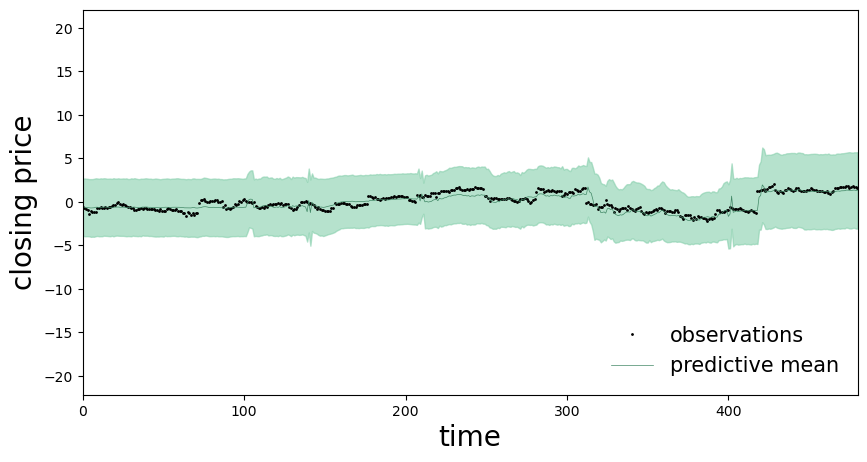

In [21]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_pre_n_tensor)

plot_predictions(preds, y_pre_n_tensor)

In [31]:
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0) 
# Calculate RMSE
y_true = y_pre_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.4758)


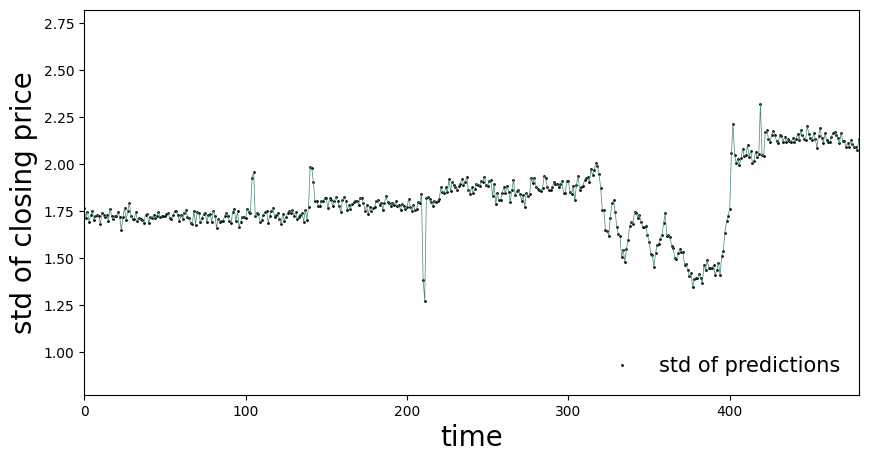

In [25]:
plot_uncertainty(preds, y_pre_n)

#### 3.1.2 Posterior BNN: ASML

In [24]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 200  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post, y_post)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 200), ##Should be more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the PRE training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 11.3967
>>> Iteration #  10: Wasserstein Dist 2.0719
>>> Iteration #  20: Wasserstein Dist 1.5477
>>> Iteration #  30: Wasserstein Dist 1.5097
>>> Iteration #  40: Wasserstein Dist 0.7448
>>> Iteration #  50: Wasserstein Dist 1.0399
>>> Iteration #  60: Wasserstein Dist 1.3517
>>> Iteration #  70: Wasserstein Dist 0.5221
>>> Iteration #  80: Wasserstein Dist 1.2195
>>> Iteration #  90: Wasserstein Dist 0.7092
>>> Iteration # 100: Wasserstein Dist 0.8997
>>> Iteration # 110: Wasserstein Dist 1.0052
>>> Iteration # 120: Wasserstein Dist 1.9221
>>> Iteration # 130: Wasserstein Dist 0.0799
>>> Iteration # 140: Wasserstein Dist -0.5235
>>> Iteration # 150: Wasserstein Dist 0.1170
>>> Iteration # 160: Wasserstein Dist 0.4167
>>> Iteration # 170: Wasserstein Dist 0.8088
>>> Iteration # 180: Wasserstein Dist 1.8563
>>> Iteration # 190: Wasserstein Dist -0.0693
>>> Iteration # 200: Wasserstein Dist 1.9302
Saved intermediate wasserstein values in: ./exp/gdpr

In [32]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.0938], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.1095], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.0538], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.4468], device='cuda:0', requires_grad=True)


In [33]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(3.1053), maintain_positivity(1.1434)]
post_bias_prior = [maintain_positivity(2.0997), maintain_positivity(-0.6430)]

In [34]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [35]:
num_epochs = 5000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 0/5000 [00:00<?, ?it/s]

[iteration 0001] loss: 814.202


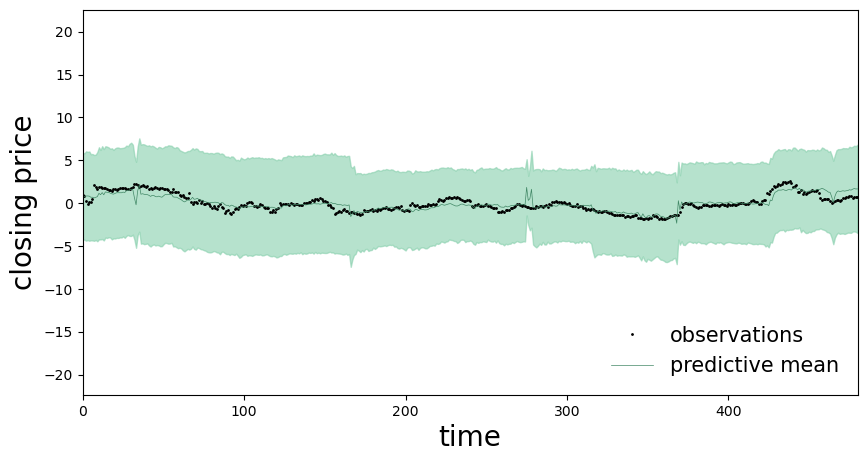

In [36]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_post_n_tensor)

plot_predictions(preds, y_post_n_tensor)

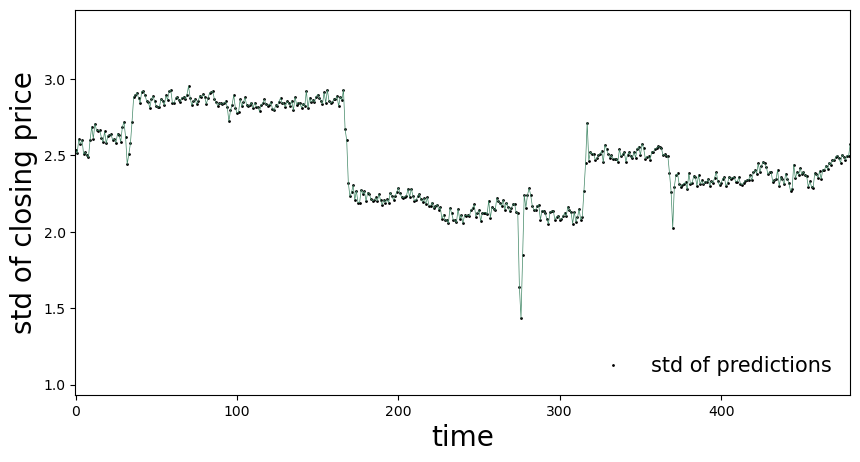

In [37]:
plot_uncertainty(preds, y_post_n)

In [38]:
##RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0) 
# Calculate RMSE
y_true = y_post_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.5464)


#### 3.2.1. Prior BNN: ATOS

In [7]:
df_pre_atos = pd.read_csv("pregdprApril2016_ATOS.csv")
df_pre_atos.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,101332527.0,64.06,10.0,1.0,1.059301,101332527.0,64.69,10.0,1.0,1.059301,...,64.90,10.0,1.0,1.059301,101332527.0,66.81,10.0,1.0,1.059301,66.436752
1,101332527.0,64.69,10.0,1.0,1.059301,101332527.0,64.55,10.0,1.0,1.059301,...,66.81,10.0,1.0,1.059301,101332527.0,67.62,10.0,1.0,1.059301,66.193655
2,101332527.0,64.55,10.0,1.0,1.059301,101332527.0,64.90,10.0,1.0,1.059301,...,67.62,10.0,1.0,1.059301,101332527.0,67.74,10.0,1.0,1.059301,67.025057
3,101332527.0,64.90,10.0,1.0,1.059301,101332527.0,66.81,10.0,1.0,1.059301,...,67.74,10.0,1.0,1.059301,101332527.0,68.26,10.0,1.0,1.059301,66.396596
4,101332527.0,66.81,10.0,1.0,1.059301,101332527.0,67.62,10.0,1.0,1.059301,...,68.26,10.0,1.0,1.059301,101332527.0,68.19,10.0,1.0,1.059301,66.402495


In [8]:
# Get both X and y from the DataFrame
X_pre_atos = df_pre_atos.iloc[:, :-1].values
y_pre_atos = df_pre_atos["target"].values

# Combine them into a single mask
valid_mask = ~np.isnan(X_pre_atos).any(axis=1) & ~np.isnan(y_pre_atos)

# Apply the same mask to both
X_pre_atos = X_pre_atos[valid_mask]
y_pre_atos = y_pre_atos[valid_mask]

In [9]:
X_pre_atos, X_pre_atos.shape, type(X_pre_atos)

(array([[1.01332527e+08, 6.40600000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.05930099e+00],
        [1.01332527e+08, 6.46900000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.05930099e+00],
        [1.01332527e+08, 6.45500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.05930099e+00],
        ...,
        [1.03523793e+08, 7.57200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.07144546e+00],
        [1.03523793e+08, 7.37800000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.07144546e+00],
        [1.03523793e+08, 7.65800000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.07144546e+00]]),
 (269, 25),
 numpy.ndarray)

In [10]:
y_pre_atos, y_pre_atos.shape, type(y_pre_atos)

(array([66.43675231, 66.19365458, 67.02505736, 66.39659582, 66.40249545,
        65.85739353, 65.54672011, 66.21159184, 68.41901454, 69.74057369,
        69.9028742 , 69.72543921, 70.05059772, 70.26310226, 72.11335583,
        70.8169484 , 70.63240904, 71.36171321, 70.5225532 , 71.1529422 ,
        70.90081565, 71.59274727, 71.69760722, 71.93920253, 72.26829442,
        71.81241305, 71.81496342, 71.90563127, 70.25588824, 70.34837211,
        70.01436712, 70.26620954, 70.62011494, 70.14662914, 70.18333708,
        71.42108796, 72.23617361, 71.24882999, 70.62118695, 70.72686636,
        70.34700624, 69.93468145, 70.03169224, 70.20163028, 70.28250355,
        70.00368636, 70.80373285, 69.25062159, 68.95814854, 68.55657803,
        70.29077194, 70.33890812, 69.89093614, 70.82323773, 70.43948262,
        70.01389438, 71.00155318, 70.1209522 , 70.57965374, 71.11391632,
        70.92466599, 71.17780136, 71.63589014, 72.61265501, 72.56221672,
        71.38897184, 71.3463526 , 70.48971421, 70.5

In [11]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre_atos, y_pre_atos)
x_min, x_max = get_input_range(X_pre_atos, y_pre_atos)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre_atos.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)

# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ###more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the post training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)
C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\models\model.py:136: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch

>>> Iteration #   1: Wasserstein Dist 16.0923
>>> Iteration #  10: Wasserstein Dist 8.3252
>>> Iteration #  20: Wasserstein Dist 8.2047
>>> Iteration #  30: Wasserstein Dist 8.4552
>>> Iteration #  40: Wasserstein Dist 8.4326
>>> Iteration #  50: Wasserstein Dist 6.6991
>>> Iteration #  60: Wasserstein Dist 6.1871
>>> Iteration #  70: Wasserstein Dist 6.9458
>>> Iteration #  80: Wasserstein Dist 6.0273
>>> Iteration #  90: Wasserstein Dist 5.3712
>>> Iteration # 100: Wasserstein Dist 5.0619
>>> Iteration # 110: Wasserstein Dist 3.0409
>>> Iteration # 120: Wasserstein Dist 5.7060
>>> Iteration # 130: Wasserstein Dist 6.0640
>>> Iteration # 140: Wasserstein Dist 5.7621
>>> Iteration # 150: Wasserstein Dist 8.0659
>>> Iteration # 160: Wasserstein Dist 4.8626
>>> Iteration # 170: Wasserstein Dist 4.6862
>>> Iteration # 180: Wasserstein Dist 5.5443
>>> Iteration # 190: Wasserstein Dist 6.1910
>>> Iteration # 200: Wasserstein Dist 7.0251
>>> Iteration # 210: Wasserstein Dist 4.6489
>>> Itera

In [12]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([6.6991], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([7.9796], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([0.7799], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-2.1555], device='cuda:0', requires_grad=True)


In [13]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(3.6905), maintain_positivity(1.3724)]
pre_bias_prior = [maintain_positivity(2.9497), maintain_positivity(-0.8432)]

In [14]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [15]:
%time
num_epochs = 10000 # number of training epoches, 10000 now for quick test: 25000
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0]))

CPU times: total: 0 ns
Wall time: 0 ns


  0%|          | 0/10000 [00:00<?, ?it/s]

[iteration 0001] loss: 61589.502
[iteration 5001] loss: 153.290


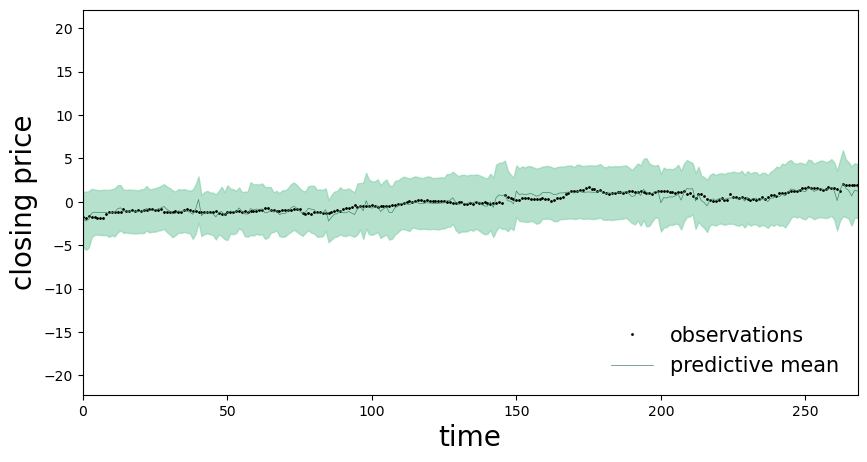

In [16]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)
preds = predictive(X_pre_n_tensor)
plot_predictions(preds, y_pre_n_tensor)

In [17]:
#RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0) 
y_true = y_pre_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.4059)


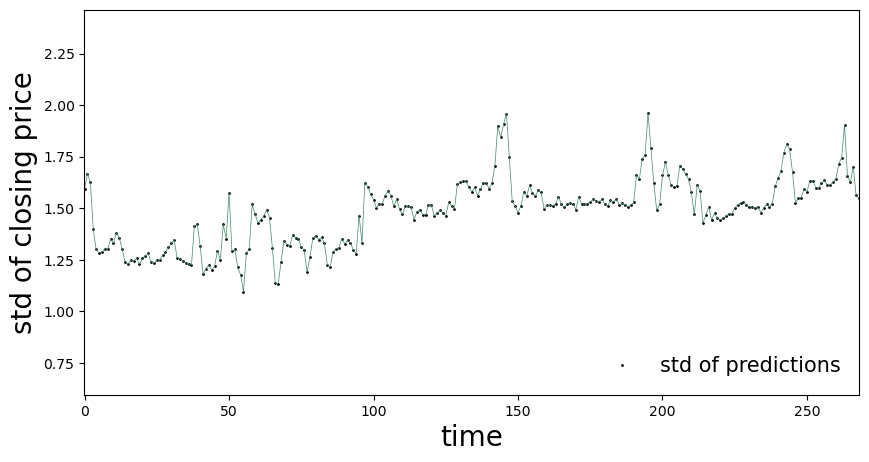

In [18]:
plot_uncertainty(preds, y_pre_n_tensor)

#### 3.2.2. Posterior BNN: ATOS

In [19]:
df_post_atos = pd.read_csv("postgdprMay2018_ATOS.csv")

In [20]:
# Extract values
X_post_atos = df_post_atos.iloc[:, :-1].values
y_post_atos = df_post_atos["target"].values

# Create a mask for rows without NaNs in either X or y
valid_mask = ~np.isnan(X_post_atos).any(axis=1) & ~np.isnan(y_post_atos)

# Apply mask to both X and y
X_post_atos = X_post_atos[valid_mask]
y_post_atos = y_post_atos[valid_mask]

In [21]:
X_post_atos, X_post_atos.shape, type(X_post_atos)

(array([[1.05598479e+08, 1.17150000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11602484e+00],
        [1.05598479e+08, 1.17150000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11602484e+00],
        [1.05598479e+08, 1.17600000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.11602484e+00],
        ...,
        [1.09195114e+08, 7.40200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51014779e+00],
        [1.09195114e+08, 7.45400000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51014779e+00],
        [1.09195114e+08, 7.53800000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.51014779e+00]]),
 (398, 25),
 numpy.ndarray)

In [22]:
y_post_atos, y_post_atos.shape, type(y_post_atos)

(array([118.72531657, 118.9868471 , 117.83229622, 122.45415181,
        122.84978913, 123.35538611, 122.83718715, 122.6852506 ,
        123.69696969, 122.86327143, 122.06777352, 121.85496098,
        120.24495789, 118.52688539, 118.87607238, 119.76789082,
        118.5058052 , 117.77121331, 118.30788725, 117.90028815,
        118.60271875, 121.6693244 , 123.30854384, 123.41987253,
        123.00995474, 123.850324  , 124.04911303, 123.26956873,
        123.16291628, 122.77185184, 114.56244754, 113.9740558 ,
        116.50418357, 113.83466109, 114.34495618, 112.90369044,
        112.08357149, 109.96210459, 111.11507464, 110.5276422 ,
        109.88335263,  97.84897612,  98.66370222,  98.42864715,
         96.97043091,  98.29420843,  98.6726412 ,  98.1022985 ,
         98.69004834,  99.38641308,  99.94324463, 101.55322457,
        101.06621525, 101.10770189, 102.64963817, 102.19028834,
        103.02733173, 103.33829144, 103.96813983, 104.30942094,
        102.72416141, 103.82106233, 102.

In [23]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post_atos, y_post_atos)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post_atos.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ##Should be more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the PRE training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 10.3642
>>> Iteration #  10: Wasserstein Dist 1.2088
>>> Iteration #  20: Wasserstein Dist 1.5595
>>> Iteration #  30: Wasserstein Dist -0.4523
>>> Iteration #  40: Wasserstein Dist 2.6792
>>> Iteration #  50: Wasserstein Dist 0.6830
>>> Iteration #  60: Wasserstein Dist -0.0757
>>> Iteration #  70: Wasserstein Dist 0.2079
>>> Iteration #  80: Wasserstein Dist 1.0261
>>> Iteration #  90: Wasserstein Dist 0.5981
>>> Iteration # 100: Wasserstein Dist 2.1084
>>> Iteration # 110: Wasserstein Dist 0.6275
>>> Iteration # 120: Wasserstein Dist 1.3859
>>> Iteration # 130: Wasserstein Dist 1.2514
>>> Iteration # 140: Wasserstein Dist 0.7259
>>> Iteration # 150: Wasserstein Dist 0.3167
>>> Iteration # 160: Wasserstein Dist 0.0321
>>> Iteration # 170: Wasserstein Dist -0.8616
>>> Iteration # 180: Wasserstein Dist 2.1949
>>> Iteration # 190: Wasserstein Dist 0.5670
>>> Iteration # 200: Wasserstein Dist 1.6679
>>> Iteration # 210: Wasserstein Dist 0.3774
>>> It

In [12]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.9592], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.9093], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1234], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.6797], device='cuda:0', requires_grad=True)


In [24]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(3.1053), maintain_positivity(1.1434)]
post_bias_prior = [maintain_positivity(2.0997), maintain_positivity(-0.6430)]

In [25]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [26]:
num_epochs = 10000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 0/10000 [00:00<?, ?it/s]

[iteration 0001] loss: 2092.400
[iteration 5001] loss: 33.749


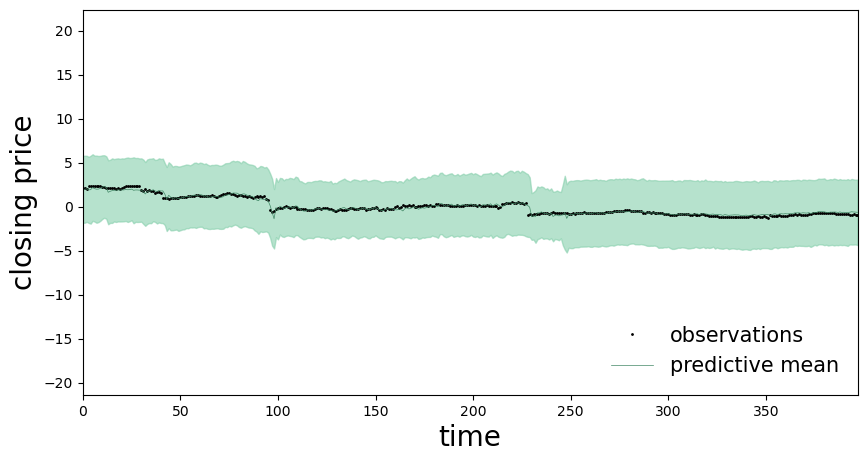

In [27]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)
preds = predictive(X_post_n_tensor)
plot_predictions(preds, y_post_n_tensor)

In [28]:
##RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0)
# Calculate RMSE
y_true = y_post_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.2091)


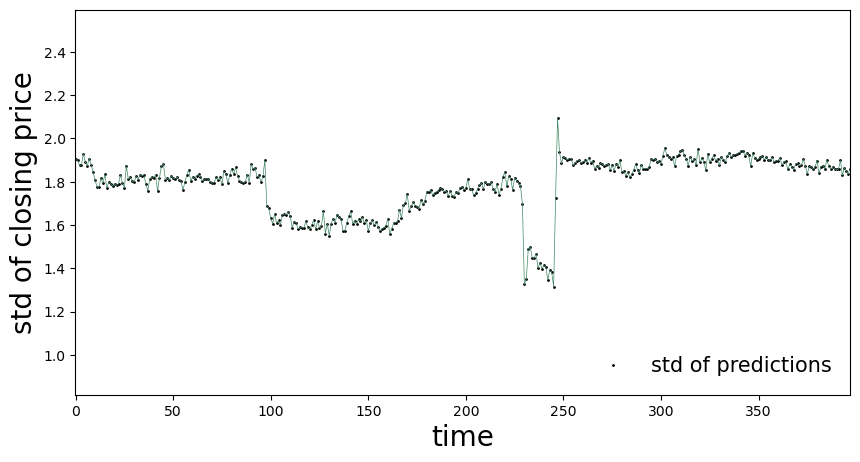

In [29]:
plot_uncertainty(preds, y_post_n)

#### 3.3.1. Prior BNN: Dassault

In [37]:
df_pre_dassault = pd.read_csv("pregdprApril2016_Dassault.csv")
df_pre_dassault.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,255723498.0,61.03,10.0,1.0,1.163192,255723498.0,61.73,10.0,1.0,1.163192,...,61.83,10.0,1.0,1.163192,255230678.0,63.35,10.0,1.0,1.163192,61.538524
1,255723498.0,61.73,10.0,1.0,1.163192,255230678.0,62.01,10.0,1.0,1.163192,...,63.35,10.0,1.0,1.163192,255230678.0,63.41,10.0,1.0,1.163192,61.742955
2,255230678.0,62.01,10.0,1.0,1.163192,255230678.0,61.83,10.0,1.0,1.163192,...,63.41,10.0,1.0,1.163192,255230678.0,63.52,10.0,1.0,1.163192,60.854215
3,255230678.0,61.83,10.0,1.0,1.163192,255230678.0,63.35,10.0,1.0,1.163192,...,63.52,10.0,1.0,1.163192,255230678.0,63.30,10.0,1.0,1.163192,60.614367
4,255230678.0,63.35,10.0,1.0,1.163192,255230678.0,63.41,10.0,1.0,1.163192,...,63.30,10.0,1.0,1.163192,255230678.0,62.60,10.0,1.0,1.163192,60.945144


In [38]:
# Get both X and y from the DataFrame
X_pre_dassault = df_pre_dassault.iloc[:, :-1].values
y_pre_dassault = df_pre_dassault["target"].values

# Combine them into a single mask
valid_mask = ~np.isnan(X_pre_dassault).any(axis=1) & ~np.isnan(y_pre_dassault)

# Apply the same mask to both
X_pre_dassault = X_pre_dassault[valid_mask]
y_pre_dassault = y_pre_dassault[valid_mask]

In [39]:
X_pre_dassault, X_pre_dassault.shape, type(X_pre_dassault)

(array([[2.55723498e+08, 6.10300000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.16319246e+00],
        [2.55723498e+08, 6.17300000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.16319246e+00],
        [2.55230678e+08, 6.20100000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.16319246e+00],
        ...,
        [2.56725586e+08, 7.12700000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.17027004e+00],
        [2.56725586e+08, 7.13200000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.17027004e+00],
        [2.56725586e+08, 6.83100000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.17027004e+00]]),
 (269, 25),
 numpy.ndarray)

In [40]:
y_pre_dassault, y_pre_dassault.shape, type(y_pre_dassault)

(array([61.53852442, 61.74295455, 60.8542151 , 60.61436726, 60.94514366,
        61.81897233, 64.62556665, 63.45225425, 66.8413532 , 66.9398132 ,
        68.05238175, 67.13263511, 66.51696291, 67.9197906 , 68.07606449,
        67.77384055, 67.30559209, 67.88407435, 67.37072308, 67.32655019,
        67.93183664, 67.84217944, 68.66282227, 68.34494517, 68.606806  ,
        68.87252653, 69.12276188, 69.27283807, 69.08648979, 68.7138416 ,
        69.37603734, 68.81131577, 68.87932557, 69.13480156, 69.22946182,
        69.69996498, 69.16447566, 69.02814149, 68.39400449, 67.6724961 ,
        68.30552903, 67.17130905, 67.42639018, 67.41212699, 66.77483212,
        67.16903547, 66.46530755, 66.06312233, 66.38106891, 65.9123806 ,
        65.69417283, 65.74160245, 66.44031723, 65.64432867, 65.10969189,
        64.85548837, 65.68128745, 64.79463496, 65.07602665, 65.50459542,
        64.88634277, 64.17099819, 64.46536637, 65.00492282, 64.91808325,
        64.14803501, 64.66642966, 63.92473042, 63.6

In [41]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre_dassault, y_pre_dassault)
x_min, x_max = get_input_range(X_pre_n, y_pre_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre_dassault.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)

# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ###more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the post training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 12.4897
>>> Iteration #  10: Wasserstein Dist 3.3199
>>> Iteration #  20: Wasserstein Dist 1.8180
>>> Iteration #  30: Wasserstein Dist 3.8412
>>> Iteration #  40: Wasserstein Dist 2.7196
>>> Iteration #  50: Wasserstein Dist 1.0647
>>> Iteration #  60: Wasserstein Dist 2.8142
>>> Iteration #  70: Wasserstein Dist 1.4975
>>> Iteration #  80: Wasserstein Dist 0.5633
>>> Iteration #  90: Wasserstein Dist 1.0018
>>> Iteration # 100: Wasserstein Dist 1.1648
>>> Iteration # 110: Wasserstein Dist 1.5652
>>> Iteration # 120: Wasserstein Dist 1.9832
>>> Iteration # 130: Wasserstein Dist 0.9291
>>> Iteration # 140: Wasserstein Dist 1.4229
>>> Iteration # 150: Wasserstein Dist 1.2887
>>> Iteration # 160: Wasserstein Dist 1.1507
>>> Iteration # 170: Wasserstein Dist 0.1543
>>> Iteration # 180: Wasserstein Dist 1.1727
>>> Iteration # 190: Wasserstein Dist 1.6194
>>> Iteration # 200: Wasserstein Dist 1.8445
>>> Iteration # 210: Wasserstein Dist 0.6680
>>> Itera

In [42]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([4.3945], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([3.0868], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.2164], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-2.0868], device='cuda:0', requires_grad=True)


In [43]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(4.3945), maintain_positivity(1.2164)]
pre_bias_prior = [maintain_positivity(3.0868), maintain_positivity(-2.0868)]

In [44]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [45]:
%time
num_epochs = 10000 # number of training epoches, 10000 now for quick test: 25000
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0]))

CPU times: total: 0 ns
Wall time: 0 ns


  0%|          | 0/10000 [00:00<?, ?it/s]

[iteration 0001] loss: 60240.688
[iteration 5001] loss: 130.068


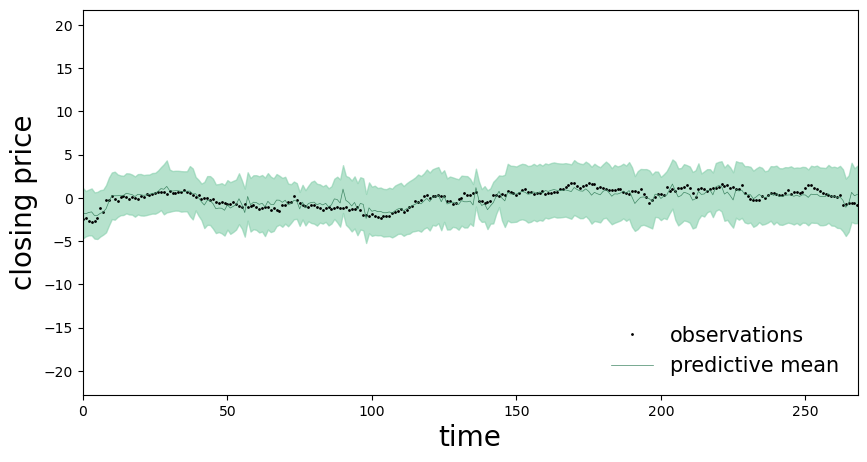

In [46]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)
preds = predictive(X_pre_n_tensor)
plot_predictions(preds, y_pre_n_tensor)

In [47]:
##RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0)
# Calculate RMSE
y_true = y_pre_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)


tensor(0.5681)


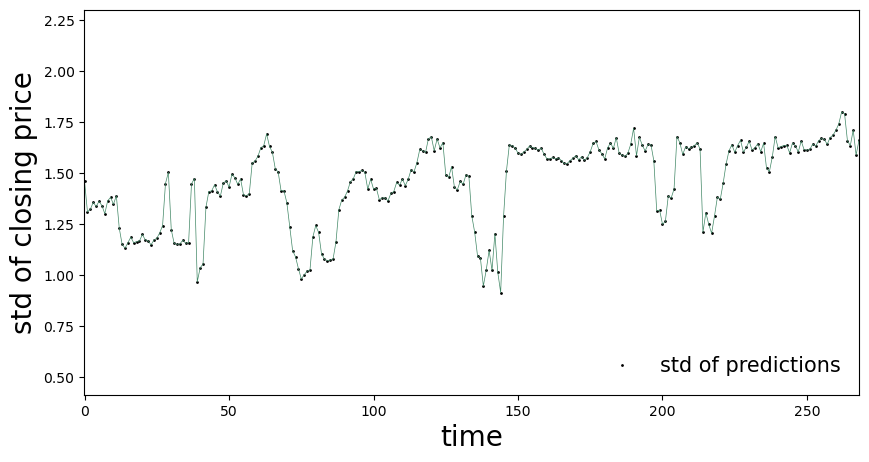

In [48]:
plot_uncertainty(preds, y_pre_n_tensor)

#### 3.3.2. Posterior BNN: Dassault

In [49]:
df_post_dassault = pd.read_csv("postgdprMay2018_Dassault.csv")
df_post_dassault.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,260506586.0,120.65,10.0,1.0,1.191664,260506586.0,121.45,10.0,1.0,1.191664,...,120.30,10.0,1.0,1.191664,260506586.0,118.75,10.0,1.0,1.191664,72.463260
1,260506586.0,121.45,10.0,1.0,1.191664,260506586.0,119.85,10.0,1.0,1.191664,...,118.75,10.0,1.0,1.191664,260506586.0,118.95,10.0,1.0,1.191664,72.526236
2,260506586.0,119.85,10.0,1.0,1.191664,260506586.0,120.30,10.0,1.0,1.191664,...,118.95,10.0,1.0,1.191664,260506586.0,118.55,10.0,1.0,1.191664,74.508429
3,260506586.0,120.30,10.0,1.0,1.191664,260506586.0,118.75,10.0,1.0,1.191664,...,118.55,10.0,1.0,1.191664,260506586.0,119.35,10.0,1.0,1.191664,74.502323
4,260506586.0,118.75,10.0,1.0,1.191664,260506586.0,118.95,10.0,1.0,1.191664,...,119.35,10.0,1.0,1.191664,260506586.0,121.85,10.0,1.0,1.191664,75.535832


In [50]:
##Extract Values
X_post_dassault = df_post_dassault.iloc[:, :-1].values
y_post_dassault = df_post_dassault["target"].values

# Create a mask for rows without NaNs in either X or y
valid_mask = ~np.isnan(X_post_dassault).any(axis=1) & ~np.isnan(y_post_dassault)

# Apply mask to both X and y
X_post_dassault = X_post_dassault[valid_mask]
y_post_dassault = y_post_dassault[valid_mask]

In [51]:
X_post_dassault, X_post_dassault.shape, type(X_post_dassault)

(array([[2.60506586e+08, 1.20650000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.19166443e+00],
        [2.60506586e+08, 1.21450000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.19166443e+00],
        [2.60506586e+08, 1.19850000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.19166443e+00],
        ...,
        [2.62927968e+08, 1.43150000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.19752138e+00],
        [2.62927968e+08, 1.43250000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.19752138e+00],
        [2.62927968e+08, 1.43850000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.19752138e+00]]),
 (398, 25),
 numpy.ndarray)

In [52]:
y_post_dassault, y_post_dassault.shape, type(y_post_dassault)

(array([72.46326003, 72.5262357 , 74.50842943, 74.50232256, 75.53583187,
        76.57507706, 76.39268269, 76.37525899, 75.25164013, 73.45801233,
        73.73675369, 73.97438282, 74.59845874, 73.82270145, 73.0707952 ,
        72.70803648, 72.66400094, 71.98984022, 72.62764333, 72.74684127,
        72.83976136, 74.35947857, 75.28881848, 76.52861812, 76.49438918,
        77.15176437, 77.89188218, 77.7023347 , 77.50102448, 76.5093257 ,
        75.52173412, 75.24501902, 73.48477162, 75.39237725, 75.40275557,
        74.40197061, 74.17470031, 74.25358222, 75.90373332, 75.019253  ,
        75.0586543 , 73.46307012, 74.46146683, 75.18833002, 75.90962332,
        77.0081488 , 78.44104714, 78.24649973, 78.34005823, 78.1356668 ,
        79.35384873, 78.55931344, 79.02810668, 80.10896386, 80.29243862,
        81.58037554, 80.90179801, 80.80184494, 81.73978026, 82.35795575,
        82.33427182, 80.42635533, 77.66465211, 77.14932824, 77.00010139,
        77.06842568, 76.82347083, 77.1600428 , 76.5

In [53]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post_dassault, y_post_dassault)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post_dassault.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ##Should be more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the PRE training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 12.4922
>>> Iteration #  10: Wasserstein Dist 1.2058
>>> Iteration #  20: Wasserstein Dist 2.1558
>>> Iteration #  30: Wasserstein Dist 2.4033
>>> Iteration #  40: Wasserstein Dist 2.2858
>>> Iteration #  50: Wasserstein Dist -1.2973
>>> Iteration #  60: Wasserstein Dist 2.2743
>>> Iteration #  70: Wasserstein Dist 0.8682
>>> Iteration #  80: Wasserstein Dist 0.4150
>>> Iteration #  90: Wasserstein Dist 0.0754
>>> Iteration # 100: Wasserstein Dist 0.1122
>>> Iteration # 110: Wasserstein Dist 1.4133
>>> Iteration # 120: Wasserstein Dist 3.2625
>>> Iteration # 130: Wasserstein Dist 1.9382
>>> Iteration # 140: Wasserstein Dist 0.0936
>>> Iteration # 150: Wasserstein Dist -0.4818
>>> Iteration # 160: Wasserstein Dist -0.7117
>>> Iteration # 170: Wasserstein Dist 1.2065
>>> Iteration # 180: Wasserstein Dist 1.2559
>>> Iteration # 190: Wasserstein Dist 0.7768
>>> Iteration # 200: Wasserstein Dist 1.3547
>>> Iteration # 210: Wasserstein Dist 1.8430
>>> It

In [54]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([3.3871], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.3243], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1624], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.4564], device='cuda:0', requires_grad=True)


In [57]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(3.3871), maintain_positivity(1.1624)]
post_bias_prior = [maintain_positivity(2.3243), maintain_positivity(-0.4564)]

In [58]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [59]:
num_epochs = 10000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 0/10000 [00:00<?, ?it/s]

[iteration 0001] loss: 180.504
[iteration 5001] loss: 26.663


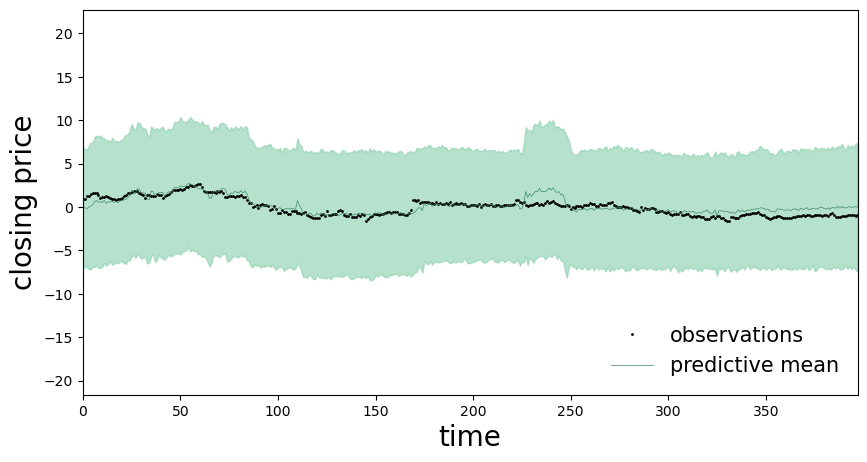

In [60]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)
preds = predictive(X_post_n_tensor)
plot_predictions(preds, y_post_n_tensor)

In [64]:
##RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0)
# Calculate RMSE
y_true = y_post_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.5552)


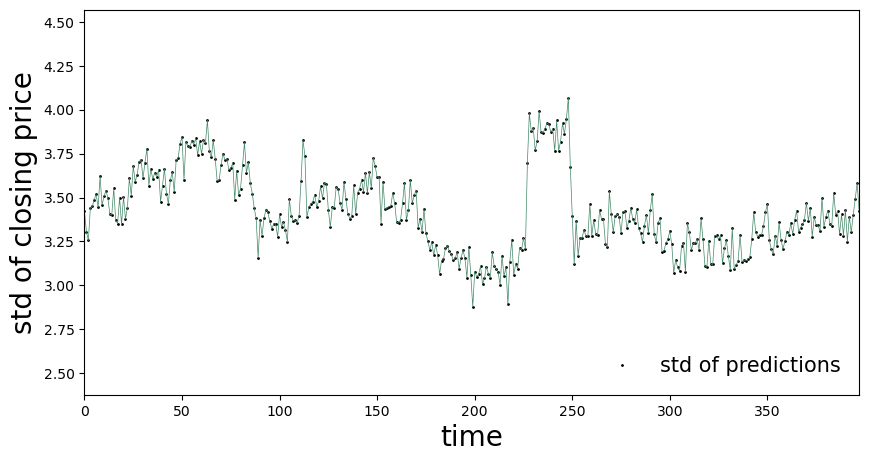

In [65]:
plot_uncertainty(preds, y_post_n_tensor)

#### 3.4.1. Prior BNN: Ericcsson

In [66]:
df_pre_ericcson = pd.read_csv("pregdprApril2016_Ericcson.csv")
df_pre_ericcson.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,261755983.0,101.0,10.0,1.0,1.535461,261755983.0,102.8,10.0,1.0,1.535461,...,103.8,10.0,1.0,1.535461,261755983.0,104.8,10.0,1.0,1.535461,103.603225
1,261755983.0,102.8,10.0,1.0,1.535461,261755983.0,103.0,10.0,1.0,1.535461,...,104.8,10.0,1.0,1.535461,261755983.0,106.1,10.0,1.0,1.535461,104.420383
2,261755983.0,103.0,10.0,1.0,1.535461,261755983.0,103.8,10.0,1.0,1.535461,...,106.1,10.0,1.0,1.535461,261755983.0,106.9,10.0,1.0,1.535461,100.434081
3,261755983.0,103.8,10.0,1.0,1.535461,261755983.0,104.8,10.0,1.0,1.535461,...,106.9,10.0,1.0,1.535461,261755983.0,103.5,10.0,1.0,1.585659,99.333622
4,261755983.0,104.8,10.0,1.0,1.535461,261755983.0,106.1,10.0,1.0,1.535461,...,103.5,10.0,1.0,1.585659,261755983.0,102.2,10.0,1.0,1.585659,98.457528


In [67]:
##Extract Values
X_pre_ericcson = df_pre_ericcson.iloc[:, :-1].values
y_pre_ericcson = df_pre_ericcson["target"].values

# Create a mask for rows without NaNs in either X or y
valid_mask = ~np.isnan(X_pre_ericcson).any(axis=1) & ~np.isnan(y_pre_ericcson)

# Apply mask to both X and y
X_pre_ericcson = X_pre_ericcson[valid_mask]
y_pre_ericcson = y_pre_ericcson[valid_mask]
X_pre_ericcson, X_pre_ericcson.shape, type(X_pre_ericcson)


(array([[2.61755983e+08, 1.01000000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.53546105e+00],
        [2.61755983e+08, 1.02800000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.53546105e+00],
        [2.61755983e+08, 1.03000000e+02, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.53546105e+00],
        ...,
        [2.61755983e+08, 7.53500000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.66165543e+00],
        [2.61755983e+08, 7.60000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.66165543e+00],
        [2.61755983e+08, 6.80000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.66165543e+00]]),
 (264, 25),
 numpy.ndarray)

In [68]:
y_pre_ericcson, y_pre_ericcson.shape, type(y_pre_ericcson)

(array([103.6032248 , 104.42038302, 100.43408099,  99.33362165,
         98.45752819, 100.0186524 , 101.23125207, 101.10614873,
         93.03767666,  92.01955163,  90.96999347,  89.93608061,
         90.25991603,  87.95710513,  87.41993472,  87.75270075,
         86.85316497,  87.9168448 ,  89.76066882,  88.83371273,
         88.29504344,  90.03784912,  90.23791613,  89.99534341,
         88.76077095,  88.62378663,  87.26629422,  86.80584723,
         88.46523094,  87.75840681,  87.89424829,  90.5017429 ,
         89.80511913,  89.71096092,  90.70142546,  89.01046448,
         91.48295834,  91.87129964,  90.25780765,  90.43761205,
         89.6759953 ,  88.69277064,  89.58862255,  87.9351845 ,
         89.01214079,  88.56280145,  87.19603858,  86.23256538,
         87.62017195,  86.0457368 ,  86.28628625,  85.95795004,
         85.29986772,  85.01117751,  86.09688731,  85.43994313,
         85.18051445,  85.62657   ,  85.69985457,  85.65977043,
         85.76486981,  86.67309166,  85.

In [69]:
%time 
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_pre_n, y_pre_n, y_mean, y_std = normalize_data(X_pre_ericcson, y_pre_ericcson)
x_min, x_max = get_input_range(X_pre_n, X_pre_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_pre_ericcson.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_pre_n, x_min, x_max, 0.7)

# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_pre_n), Y=torch.from_numpy(y_pre_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ###more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the post training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

CPU times: total: 0 ns
Wall time: 0 ns


C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 11.1652
>>> Iteration #  10: Wasserstein Dist 3.6412
>>> Iteration #  20: Wasserstein Dist 3.7002
>>> Iteration #  30: Wasserstein Dist 3.7740
>>> Iteration #  40: Wasserstein Dist -1.6925
>>> Iteration #  50: Wasserstein Dist 1.2859
>>> Iteration #  60: Wasserstein Dist 0.8255
>>> Iteration #  70: Wasserstein Dist 2.7083
>>> Iteration #  80: Wasserstein Dist 2.5183
>>> Iteration #  90: Wasserstein Dist 1.3185
>>> Iteration # 100: Wasserstein Dist 0.9242
>>> Iteration # 110: Wasserstein Dist 1.4558
>>> Iteration # 120: Wasserstein Dist 1.4181
>>> Iteration # 130: Wasserstein Dist 0.1063
>>> Iteration # 140: Wasserstein Dist 1.0562
>>> Iteration # 150: Wasserstein Dist 1.2150
>>> Iteration # 160: Wasserstein Dist -0.7338
>>> Iteration # 170: Wasserstein Dist 0.9411
>>> Iteration # 180: Wasserstein Dist 1.7758
>>> Iteration # 190: Wasserstein Dist 2.4295
>>> Iteration # 200: Wasserstein Dist -0.2371
>>> Iteration # 210: Wasserstein Dist 0.7826
>>> It

In [70]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([4.7054], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([3.7491], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.1502], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-1.8061], device='cuda:0', requires_grad=True)


In [71]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

pre_weight_prior = [maintain_positivity(4.7054), maintain_positivity(1.1502)]
pre_bias_prior = [maintain_positivity(3.7491), maintain_positivity(-1.8061)]

In [72]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(pre_weight_prior, pre_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [73]:
%time
num_epochs = 10000 # number of training epoches, 10000 now for quick test: 25000
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_pre_n_tensor = torch.tensor(X_pre_n, dtype=torch.float)
y_pre_n_tensor = torch.tensor(y_pre_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_pre_n_tensor, y_pre_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_pre_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_pre_n.shape[0]))

CPU times: total: 0 ns
Wall time: 0 ns


  0%|          | 0/10000 [00:00<?, ?it/s]

[iteration 0001] loss: 10126.306
[iteration 5001] loss: 46.206


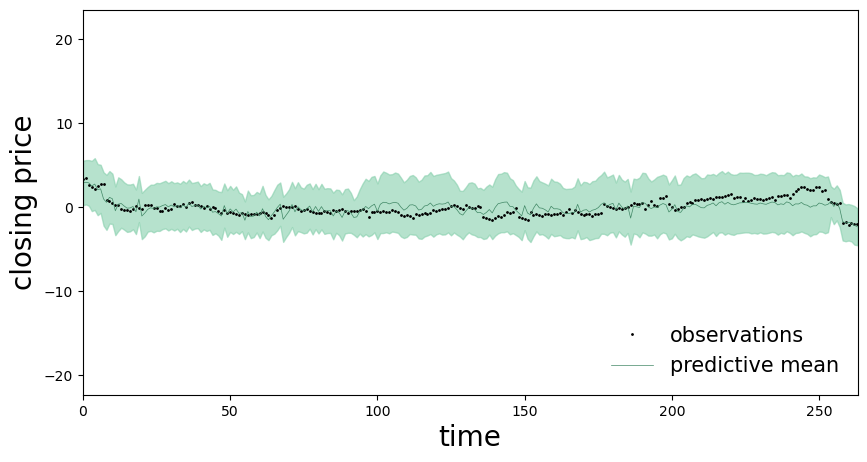

In [74]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)

preds = predictive(X_pre_n_tensor)

plot_predictions(preds, y_pre_n_tensor)

In [75]:
#RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0)
# Calculate RMSE
y_true = y_pre_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.7565)


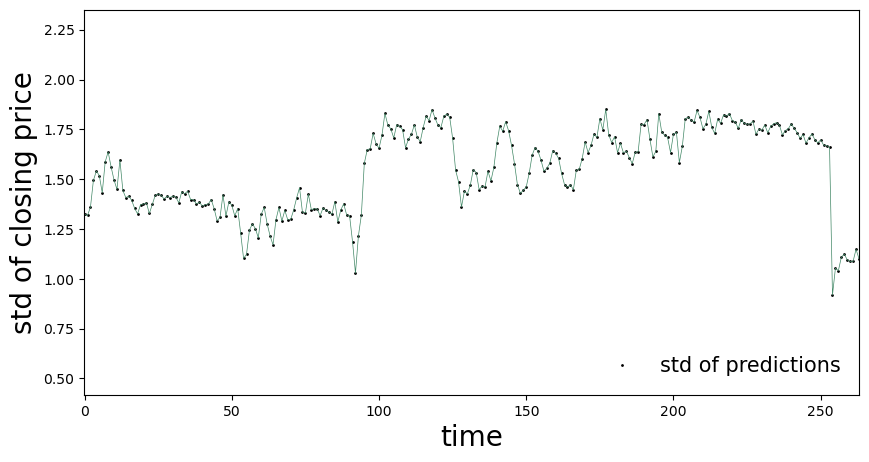

In [76]:
plot_uncertainty(preds, y_pre_n_tensor)

#### 3.4.2. Posterior BNN: Ericcsson

In [77]:
df_post_ericcson = pd.read_csv("postgdprMay2018_Ericcson.csv")
df_post_ericcson.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,target
0,261755983.0,63.8,10.0,1.0,1.721164,261755983.0,63.5,10.0,1.0,1.721164,...,62.4,10.0,1.0,1.721164,261755983.0,62.0,10.0,1.0,1.721164,78.598425
1,261755983.0,63.5,10.0,1.0,1.721164,261755983.0,62.7,10.0,1.0,1.721164,...,62.0,10.0,1.0,1.721164,261755983.0,62.3,10.0,1.0,1.721164,81.958706
2,261755983.0,62.7,10.0,1.0,1.721164,261755983.0,62.4,10.0,1.0,1.721164,...,62.3,10.0,1.0,1.721164,261755983.0,63.6,10.0,1.0,1.721164,82.863704
3,261755983.0,62.4,10.0,1.0,1.721164,261755983.0,62.0,10.0,1.0,1.721164,...,63.6,10.0,1.0,1.721164,261755983.0,65.7,10.0,1.0,1.721164,82.616020
4,261755983.0,62.0,10.0,1.0,1.721164,261755983.0,62.3,10.0,1.0,1.721164,...,65.7,10.0,1.0,1.721164,261755983.0,67.1,10.0,1.0,1.721164,83.207702


In [78]:
#Extract Values
X_post_ericcson = df_post_ericcson.iloc[:, :-1].values
y_post_ericcson = df_post_ericcson["target"].values

# Create a mask for rows without NaNs in either X or y
valid_mask = ~np.isnan(X_post_ericcson).any(axis=1) & ~np.isnan(y_post_ericcson)

# Apply mask to both X and y
X_post_ericcson = X_post_ericcson[valid_mask]
y_post_ericcson = y_post_ericcson[valid_mask]
X_post_ericcson, X_post_ericcson.shape, type(X_post_ericcson)

(array([[2.61755983e+08, 6.38000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.72116375e+00],
        [2.61755983e+08, 6.35000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.72116375e+00],
        [2.61755983e+08, 6.27000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.72116375e+00],
        ...,
        [2.61755983e+08, 8.51000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.74115404e+00],
        [2.61755983e+08, 8.55000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.74115404e+00],
        [2.61755983e+08, 8.70000000e+01, 1.00000000e+01, ...,
         1.00000000e+01, 1.00000000e+00, 1.74115404e+00]]),
 (389, 25),
 numpy.ndarray)

In [79]:
y_post_ericcson, y_post_ericcson.shape, type(y_post_ericcson)

(array([ 78.59842488,  81.95870643,  82.86370442,  82.61602043,
         83.20770237,  86.1705548 ,  86.93477066,  84.77553639,
         84.53745071,  83.86188259,  84.30710554,  83.30927248,
         85.5364581 ,  84.67808543,  82.75911643,  81.61228306,
         81.90226657,  83.16005061,  82.89991043,  83.55026543,
         84.09792478,  85.06813587,  85.42516464,  83.94829104,
         84.12592007,  90.48415245,  91.15079534,  89.45393926,
         89.52157927,  89.23152271,  89.67287798,  87.17776196,
         86.03570498,  85.45388775,  84.1862738 ,  85.89494583,
         87.5031066 ,  86.10491824,  86.06956188,  86.84555184,
         87.68516836,  87.83171246,  87.63198959,  87.93022772,
         88.19735189,  88.46882608,  89.45382941,  89.15991533,
         90.50718405,  91.90097156,  92.13930397,  94.8089543 ,
         97.4819094 ,  97.65988795,  98.25783065,  98.12220925,
         96.22196082,  96.51852965,  97.86566536,  98.00929751,
         96.68044983, 100.5472203 ,  99.

In [80]:
noise_var = 0.1
n_units = 128
n_hidden = 1
activation_fn = "tanh"
num_iters = 300  # Number of iteterations of Wasserstein optimization
lr = 0.05        # The learning rate
n_samples = 128  # The mini-batch size
out_dir = "./exp/gdpr/optim_gaussian"

X_post_n, y_post_n, y_mean, y_std = normalize_data(X_post_ericcson, y_post_ericcson)
x_min, x_max = get_input_range(X_post_n, X_post_n)
epsilon = 1e-6
x_min = np.minimum(x_min, x_max - epsilon)
input_dim, output_dim = int(X_post_ericcson.shape[-1]), 1
    
# Initialize the measurement set generator
rand_generator = MeasureSetGenerator(X_post_n, x_min, x_max, 0.7)
    
# Initialize the mean and covariance function of the target hierarchical GP prior
mean = mean_functions.Zero()
    
lengthscale = math.sqrt(2. * input_dim)
variance = 1.
kernel = kernels.RBF(input_dim=input_dim,
                     lengthscales=torch.tensor([lengthscale], dtype=torch.double),
                     variance=torch.tensor([variance], dtype=torch.double), ARD=True)

# Place hyper-priors on lengthscales and variances
kernel.lengthscales.prior = priors.LogNormal(
    torch.ones([input_dim]) * math.log(lengthscale),
    torch.ones([input_dim]) * 1.)
kernel.variance.prior = priors.LogNormal(
    torch.ones([1]) * 0.1,
    torch.ones([1]) * 1.)
        
# Initialize the GP model
gp = GPR(X=torch.from_numpy(X_post_n), Y=torch.from_numpy(y_post_n).reshape([-1, 1]),
             kern=kernel, mean_function=mean)
gp.likelihood.variance.set(noise_var)
    
# Initialize tunable MLP prior
hidden_dims = [n_units] * n_hidden
mlp_reparam = GaussianMLPReparameterization(input_dim, output_dim,
    hidden_dims, activation_fn, scaled_variance=True)
    
mapper = MapperWasserstein(gp, mlp_reparam, rand_generator, out_dir=out_dir,
                               output_dim=output_dim, n_data=100,
                               wasserstein_steps=(0, 300), ##Should be more than 200
                               wasserstein_lr=0.02,
                               logger=None, wasserstein_thres=0.1,
                               n_gpu=1, gpu_gp=True) ##Change GPU if you don't have CUDA; same thing for the PRE training
    
w_hist = mapper.optimize(num_iters=num_iters, n_samples=n_samples,
                             lr=lr, print_every=10, save_ckpt_every=10, debug=True)

print("----" * 20)

C:\Users\thumo\OneDrive - Georgia Institute of Technology\Georgia Tech\Semesters\Spring 2025\CSE 8803 IUQ\Project\2-BNN_trained_prior\you-need-a-good-prior\optbnn\gp\parameter.py:63: UserWarning: An output with one or more elements was resized since it had shape [1], which does not match the required output shape []. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\Resize.cpp:37.)
  return torch.log(torch.exp(t) - 1, out=out)


>>> Iteration #   1: Wasserstein Dist 6.4731
>>> Iteration #  10: Wasserstein Dist 2.2220
>>> Iteration #  20: Wasserstein Dist 0.9083
>>> Iteration #  30: Wasserstein Dist 1.4609
>>> Iteration #  40: Wasserstein Dist 0.4510
>>> Iteration #  50: Wasserstein Dist 0.8844
>>> Iteration #  60: Wasserstein Dist 0.3588
>>> Iteration #  70: Wasserstein Dist 2.4069
>>> Iteration #  80: Wasserstein Dist 2.3103
>>> Iteration #  90: Wasserstein Dist 1.7260
>>> Iteration # 100: Wasserstein Dist 1.1724
>>> Iteration # 110: Wasserstein Dist -0.4087
>>> Iteration # 120: Wasserstein Dist 1.1350
>>> Iteration # 130: Wasserstein Dist 0.3444
>>> Iteration # 140: Wasserstein Dist -0.2457
>>> Iteration # 150: Wasserstein Dist -0.0511
>>> Iteration # 160: Wasserstein Dist -0.0645
>>> Iteration # 170: Wasserstein Dist 1.0946
>>> Iteration # 180: Wasserstein Dist 1.1014
>>> Iteration # 190: Wasserstein Dist -0.4468
>>> Iteration # 200: Wasserstein Dist 0.1830
>>> Iteration # 210: Wasserstein Dist -1.5146
>>> 

In [81]:
for name, param in mlp_reparam.named_parameters():
    print(f"parameter name: {name}, parameter shape: {param}")

parameter name: layers.0.W_std, parameter shape: Parameter containing:
tensor([2.8332], device='cuda:0', requires_grad=True)
parameter name: layers.0.b_std, parameter shape: Parameter containing:
tensor([2.0003], device='cuda:0', requires_grad=True)
parameter name: output_layer.W_std, parameter shape: Parameter containing:
tensor([1.0969], device='cuda:0', requires_grad=True)
parameter name: output_layer.b_std, parameter shape: Parameter containing:
tensor([-0.1846], device='cuda:0', requires_grad=True)


In [82]:
def maintain_positivity(x):
    '''
    maintain the positivity of weight and bias standard derivations
    '''
    return np.log(1 + np.exp(x))

post_weight_prior = [maintain_positivity(2.8332), maintain_positivity(1.0969)]
post_bias_prior = [maintain_positivity(2.0003), maintain_positivity(-0.1846)]

In [83]:
# clear parameters to ensure every training start from scratch
pyro.clear_param_store()

# set up BNN
model_VI = BNN(post_weight_prior, post_bias_prior, in_dim=25, out_dim=1, hid_dim=128, n_hid_layers=1)

#mean_field_guide = AutoDiagonalNormal(model_VI) # mean field variational inference
guide = AutoMultivariateNormal(model_VI) # use multivariate normal with full covariance to approxiamte posterior

# apply SGD to maximizing the ELBO
optimizer = pyro.optim.Adam({"lr": 0.001})
svi = SVI(model_VI, guide, optimizer, loss=Trace_ELBO())

# # clear parameters to avoid influencing others
pyro.clear_param_store()

In [84]:
num_epochs = 10000 # number of training epoches, 10000 now for quick test
progress_bar = trange(num_epochs) # show progress bar (only for visualization purpose)

X_post_n_tensor = torch.tensor(X_post_n, dtype=torch.float)
y_post_n_tensor = torch.tensor(y_post_n, dtype=torch.float)

for epoch in progress_bar:
    loss = svi.step(X_post_n_tensor, y_post_n_tensor)
    progress_bar.set_postfix(loss=f"{loss / X_post_n.shape[0]:.3f}")
    if epoch % 5000 == 0:
        print("[iteration %04d] loss: %.3f" % (epoch + 1, loss / X_post_n.shape[0]))

  0%|          | 0/10000 [00:00<?, ?it/s]

[iteration 0001] loss: 2170.256
[iteration 5001] loss: 19.600


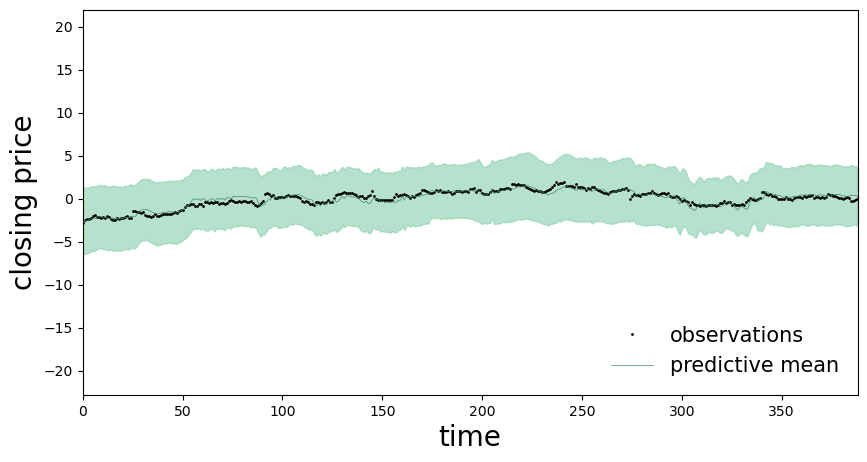

In [85]:
predictive = Predictive(model_VI, guide=guide, num_samples=1000)
preds = predictive(X_post_n_tensor)
plot_predictions(preds, y_post_n_tensor)

In [86]:
#RMSE
pred_samples = preds["obs"]
pred_mean = pred_samples.mean(dim=0)
# Calculate RMSE
y_true = y_post_n_tensor
rmse = torch.sqrt(torch.mean((pred_mean - y_true) ** 2))
print(rmse)

tensor(0.3769)


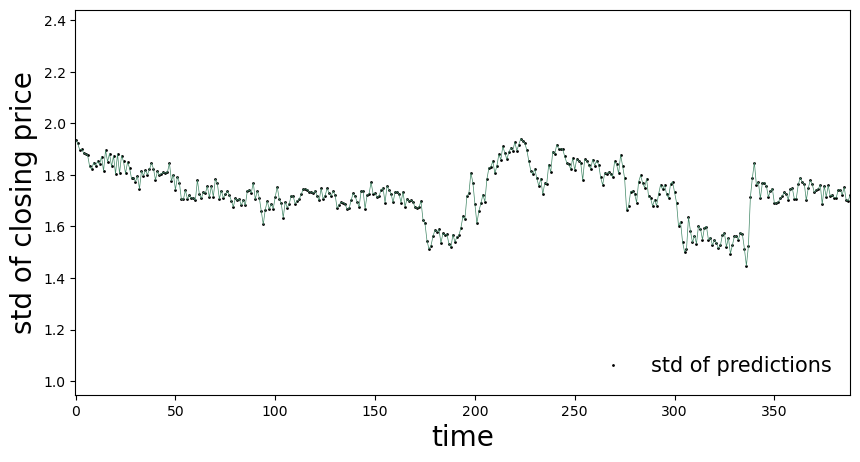

In [87]:
plot_uncertainty(preds, y_post_n_tensor)